# Calibrating a local optical potential to a real measurement

This is the production path from start to finish. We take a measurement as EXFOR reports it, convert it into the library's units, calibrate a local [optical potential](https://doi.org/10.1016/S0375-9474(02)01321-0) against it with nested sampling, and predict on angles the experiment never measured.

The data are real, and that shapes everything that follows. They're [EXFOR entry O1199](https://www-nds.iaea.org/exfor/), subentry O1199007: $p + {}^{40}\mathrm{Ca}$ elastic scattering at 35 MeV, reported as a ratio to the Rutherford cross section at 59 angles from 6 to 163 degrees. The statistical errors are about 2.3 %, and **no systematic uncertainty is quoted at all**.

We'll calibrate the same potential twice, with two different statistical models, and compare them:

1. **Log-space residuals with an inferred error model**: the reported statistical errors, plus the two relative error terms of the `jitr` [$\alpha$ + Ca Bayesian calibration notebook](https://github.com/beykyle/jitr/blob/main/examples/notebooks/alpha_ca_calibration.ipynb), one uncorrelated from point to point and one common to all points.
2. **Linear residuals with only the reported statistical errors**, which is what we get if we take the measurement entirely at its word.

We'll judge them in three ways: **(A)** the evidence; **(B)** the posterior predictive, both for the potential alone and for the potential plus every error term; and **(C)** the empirical coverage of each of those predictives.

Recipes: 10, 14, 15, 16, 17, 18, 19, 21, 40

In [1]:
import corner
import dynesty
import jitr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotstyle
from jitr.optical_potentials.potential_forms import (
    coulomb_charged_sphere,
    thomas_safe,
    woods_saxon_prime_safe,
    woods_saxon_safe,
)
from scipy import stats

import rxmc as rx
from rxmc import transforms as tf

plotstyle.use()

## The measurement

We pulled the file from the EXFOR database once and committed it next to this notebook, so the notebook runs anywhere. The query looked like this:

```python
import exfor_tools as et
from exfor_tools import curate

reaction = et.reaction.Reaction(target=(40, 20), projectile=(1, 1), process="EL")
entries, failed = curate.query_for_entries(reaction=reaction, quantity="dXS/dRuth")
```

`process="EL"` is the part worth remembering. EXFOR spells elastic scattering `(P,EL)`, and asking for a product tuple instead silently returns nothing.

`exfor_tools` hands back a `Distribution` object. Here we don't want to depend on the database, so we stand in for it with a plain `dict` carrying the same fields. `rx.from_measurement` accepts either.

In [2]:
df = pd.read_csv("data/p40ca_elastic_35mev.csv")
measurement = {
    "x": df["angle_cm_deg"].to_numpy(),  # degrees
    "y": df["ratio_to_rutherford"].to_numpy(),
    "statistical_err": df["stat_err"].to_numpy(),
    "Einc": 35.0,
    "quantity": "dXS/dRuth",
    "y_units": "no-dim",
    "x_units": "CM-degrees",
    "systematic_norm_err": 0.0,  # this entry quotes none
    "systematic_offset_err": 0.0,
    "subentry": "O1199007",
}

In [3]:
x_deg, y_meas, y_stat = (
    measurement["x"],
    measurement["y"],
    measurement["statistical_err"],
)
print(f"{x_deg.size} angles, {x_deg.min():.1f} to {x_deg.max():.1f} deg")
print(f"relative statistical error: {np.mean(y_stat / y_meas):.1%}")

59 angles, 6.3 to 163.3 deg
relative statistical error: 2.3%


## `from_measurement`: the unit contract

`from_measurement` puts the measurement into the library's internal units. Angles become radians and cross sections become b/sr. Every error with dimensions is converted along with the data, while a *fractional* normalisation error passes through untouched, since it has no units to convert. The kinematics a reaction model needs to bind land in `meta`.

This particular measurement exercises two parts of that contract. First, its angles are in the **CM frame**. A LAB-frame entry would be refused outright rather than silently mis-analysed. Second, because it's a ratio to Rutherford, asking for `dXS/dA` instead converts it through the Rutherford cross section, which is a closed-form function of the kinematics (recipe 14).

In [4]:
reaction = jitr.reactions.ElasticReaction(target=(40, 20), projectile=(1, 1))
data = rx.from_measurement(measurement, reaction=reaction)
absolute = rx.from_measurement(measurement, reaction=reaction, quantity="dXS/dA")

In [5]:
print(data)
print(f"ratio:    y[:3] = {data.y[:3].round(3)} (dimensionless)")
print(f"absolute: y[:3] = {absolute.y[:3].round(4)} b/sr")
print("meta:", {key: v for key, v in data.meta.items() if key != "reaction"})

Dataset('O1199007', n=59)
ratio:    y[:3] = [1.41 1.93 2.05] (dimensionless)
absolute: y[:3] = [71.2624 18.1398  7.6554] b/sr
meta: {'quantity': 'dXS/dRuth', 'Elab': 35.0, 'subentry': 'O1199007', 'k': 1.277431188612647, 'eta': 0.5484365614354219}


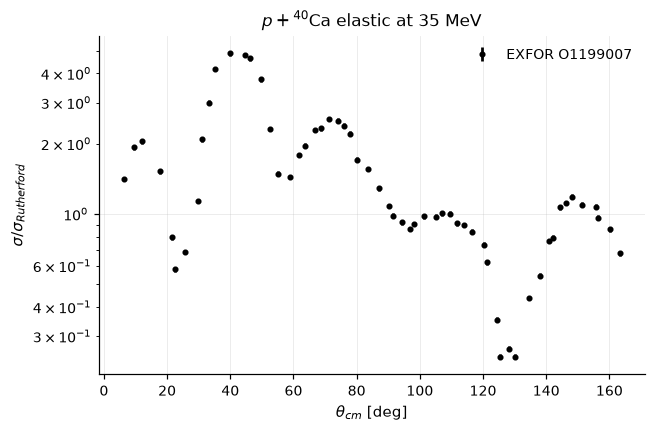

In [6]:
fig, ax = plt.subplots()
ax.errorbar(
    np.rad2deg(data.x),
    data.y,
    data.y_err,
    fmt="o",
    ms=3,
    color="k",
    label=f"EXFOR {measurement['subentry']}",
)
ax.set(
    xlabel=r"$\theta_{cm}$ [deg]",
    ylabel=r"$\sigma / \sigma_{Rutherford}$",
    yscale="log",
    title=r"$p + {}^{40}$Ca elastic at 35 MeV",
)
ax.legend()
plt.show()

## The potential

We use a [Woods–Saxon](https://en.wikipedia.org/wiki/Woods%E2%80%93Saxon_potential) potential with volume and surface absorption, a fixed spin-orbit term, and, because the proton is charged, a Coulomb term from a uniformly charged sphere. `ElasticXS` is a `Model` whose `bind` compiles a [jitr](https://github.com/beykyle/jitr) solver for the dataset's kinematics, which it reads from `meta` (recipe 15).

The model's quantity and the dataset's have to agree. If we tried to compare a ratio-to-Rutherford measurement with a `dXS/dA` model, the `Comparison` would refuse at construction, rather than letting us discover the mismatch after a fit.

In [7]:
A13 = 40 ** (1 / 3)
mso = 1.0 / jitr.utils.constants.WAVENUMBER_PION


def central(r, Vv, Wv, Rv, av, Wd, Rd, ad):
    return -(Vv + 1j * Wv) * woods_saxon_safe(r, Rv, av) - 1j * Wd * (
        -4 * ad
    ) * woods_saxon_prime_safe(r, Rd, ad)


def spin_orbit(r, Vso, Rso, aso):
    return Vso * mso**2 * thomas_safe(r, Rso, aso)


def coulomb(r):
    return coulomb_charged_sphere(
        r, reaction.target.Z * reaction.projectile.Z, 1.3 * A13
    )


so_args = (5.5, 1.0 * A13, 0.6)  # held fixed, no Ay

In [8]:
names = ["Vv", "Wv", "Rv", "av", "Wd", "Rd", "ad"]
latex = ["V_v", "W_v", "R_v", "a_v", "W_d", "R_d", "a_d"]
start = np.array([45.0, 3.0, 1.18 * A13, 0.68, 6.0, 1.28 * A13, 0.55])
prior_sd = np.array([8.0, 3.0, 0.25, 0.15, 5.0, 0.25, 0.15])
lower = np.array([0.0, 0.0, 1.0, 0.2, 0.0, 1.0, 0.2])
params = [
    rx.Parameter(n, prior=stats.norm(mu, sd), bounds=(lo, np.inf), latex=lt)
    for n, mu, sd, lo, lt in zip(names, start, prior_sd, lower, latex)
]
omp = rx.reactions.ElasticXS(
    "dXS/dRuth",
    central,
    spin_orbit,
    lambda ws, *x: (tuple(x), so_args),
    params,
    coulomb=coulomb,
    lmax=30,
)

## Two statistical models for the same potential

### 1. Log space, with an inferred error model

The measurement spans more than three decades, and the disagreement between a local potential and real data is naturally *relative*: a few per cent of the cross section, whatever its size. So the first model compares in log space (recipe 10), with residuals $r_i = \log y_i - \log y_m(\theta_i)$.

On top of the reported statistical errors we add the error model of the `jitr` [$\alpha$ + Ca calibration](https://github.com/beykyle/jitr/blob/main/examples/notebooks/alpha_ca_calibration.ipynb). Think of each measured point as the prediction multiplied by two independent [log-normal](https://en.wikipedia.org/wiki/Log-normal_distribution) factors, $y_i = y_{m,i}\,A_i\,B$, both with mean one:

- $A_i$ is a **relative error uncorrelated from point to point**, one for each angle;
- $B$ is a **relative error common to all points**, like an uncertain normalisation, or more generally a coherent misfit of the model.

If we choose $\mathrm{Var}[B] = b^2$ and $\mathrm{Var}[A_i] = s^2/(1+b^2)$, the covariance in linear space comes out as exactly $(s^2 + b^2)\,y_{m,i}^2$ on the diagonal and $b^2\,y_{m,i}\,y_{m,j}$ off it. In log space it becomes the same at every angle:

$$\Sigma^{\log}_{ij} = \sigma_{\mathrm{stat},i}^2\,\delta_{ij} + \log\!\left(1 + \frac{s^2}{1+b^2}\right)\delta_{ij} + \log\!\left(1 + b^2\right),$$

where the first term is the reported statistical error carried into log space, $\sigma_i / y_i$. None of the helpers in `rxmc.terms` writes this exact form, so we write it ourselves as two one-line `rx.Term`s (recipe 19): a diagonal that reads both $s$ and $b$, and a mode that reads $b$. For small errors, $\log(1+x) \approx x$, and the pair reduces to `T.noise` plus `T.offset`. As in `jitr`, both $s$ and $b$ get log-uniform priors between 5 % and 200 %.

### 2. Linear space, with the reported errors alone

The second model is the simplest thing we could do: compare the ratios directly, with the reported 2.3 % statistical errors as the whole covariance. It tells the sampler that every disagreement between potential and data is a statistical fluctuation.

In [9]:
def log_uniform(lo, hi):
    return stats.uniform(np.log(lo), np.log(hi) - np.log(lo))


log_s = rx.Parameter("log_s", prior=log_uniform(0.05, 2.0), latex=r"\log s")
log_b = rx.Parameter("log_b", prior=log_uniform(0.05, 2.0), latex=r"\log b")


def point_to_point_sd(c, log_s, log_b):
    s2, b2 = np.exp(2 * log_s), np.exp(2 * log_b)
    return np.full(len(c), np.sqrt(np.log1p(s2 / (1 + b2))))


def common_sd(c, log_b):
    return np.full(len(c), np.sqrt(np.log1p(np.exp(2 * log_b))))


point_to_point = rx.Term(point_to_point_sd, (log_s, log_b), kind="diag")
common = rx.Term(common_sd, (log_b,), kind="mode")

In [10]:
comp_log = rx.Comparison(data, omp, space=tf.log)
comp_lin = rx.Comparison(data, omp)
problems = {
    "log space, inferred errors": rx.Problem(
        [rx.Constraint([comp_log], terms=[point_to_point, common])]
    ),
    "linear, reported errors": rx.Problem([rx.Constraint([comp_lin])]),
}
# the inferred terms of each model: functions of the angle alone, so they have a
# value on any grid, unlike the reported per-point statistical errors
inferred_terms = {
    "log space, inferred errors": [point_to_point, common],
    "linear, reported errors": [],
}
colours = {
    "log space, inferred errors": plotstyle.COLOURS[0],
    "linear, reported errors": plotstyle.COLOURS[1],
}

In [11]:
for name, p in problems.items():
    print(f"{name:28s} {p.ndim} columns: {p.names}")
chi2_start = problems["linear, reported errors"].chi2(start) / data.n
print(f"\nchi2 per point at the starting potential, reported errors: {chi2_start:.1f}")

log space, inferred errors   9 columns: ['Vv', 'Wv', 'Rv', 'av', 'Wd', 'Rd', 'ad', 'log_s', 'log_b']
linear, reported errors      7 columns: ['Vv', 'Wv', 'Rv', 'av', 'Wd', 'Rd', 'ad']



chi2 per point at the starting potential, reported errors: 987.0


## Calibrating with nested sampling (recipe 16)

Optical-model posteriors are correlated and often multimodal, and an affine-invariant ensemble sampler mixes poorly on them. [Nested sampling](https://en.wikipedia.org/wiki/Nested_sampling_algorithm) ([Skilling 2006](https://doi.org/10.1214/06-BA127)), here through [dynesty](https://dynesty.readthedocs.io/) ([Speagle 2020](https://doi.org/10.1093/mnras/staa278)), copes much better, and it returns the evidence as a by-product. It needs two callables, `log_likelihood` and `prior_transform`. The transform maps the unit cube through every parameter's truncated prior, and the problem assembles it for us.

In [12]:
def nested(problem, seed, nlive=150, dlogz=0.5):
    sampler = dynesty.NestedSampler(
        problem.log_likelihood,
        problem.prior_transform,
        problem.ndim,
        nlive=nlive,
        sample="rwalk",
        rstate=np.random.default_rng(seed),
    )
    sampler.run_nested(dlogz=dlogz, print_progress=False)
    return sampler.results


results, samples = {}, {}
for i, (name, p) in enumerate(problems.items()):
    results[name] = nested(p, seed=1 + i)
    samples[name] = results[name].samples_equal(rstate=np.random.default_rng(1 + i))

In [13]:
for name, res in results.items():
    print(
        f"{name:28s} log Z = {res.logz[-1]:9.2f} +/- {res.logzerr[-1]:.2f}, "
        f"{int(np.sum(res.ncall)):7d} calls"
    )

log space, inferred errors   log Z =    -27.64 +/- 0.49,   64063 calls
linear, reported errors      log Z =  -3479.53 +/- 0.72,  128259 calls


## (A) The evidence

The [evidence](https://en.wikipedia.org/wiki/Marginal_likelihood) is the probability each statistical model assigned to the measured data, averaged over its prior, and the ratio of two evidences is the [Bayes factor](https://en.wikipedia.org/wiki/Bayes_factor) between them. There's one subtlety here. The raw $\log Z$ from the log-space fit is a density for $\log y$, while the linear fit's is a density for $y$ itself. Adding `problem.log_jacobian()` converts the first into a density for $y$, the [change of variables](https://en.wikipedia.org/wiki/Probability_density_function#Function_of_random_variables_and_change_of_variables_in_the_probability_density_function) $\sum_i \log |\mathrm{d}\log y_i / \mathrm{d}y_i|$, and only then are the two comparable (recipe 18).

In [14]:
logz = {
    name: rx.diagnostics.logz_summary(
        results[name].logz[-1] + problems[name].log_jacobian(),
        results[name].logzerr[-1],
    )
    for name in problems
}
verdict = rx.diagnostics.compare_logz(
    logz["log space, inferred errors"], logz["linear, reported errors"]
)

In [15]:
for name, (mean, err, _) in logz.items():
    print(f"{name:28s} log Z = {mean:9.2f} +/- {err:.2f}  (density of the ratios)")
words = {"a": "log space favoured", "b": "linear favoured", "tie": "a tie"}
print(
    f"\ndlogZ = {verdict['dlogZ']:.1f} +/- {verdict['err']:.1f}"
    f"  ->  {words[verdict['verdict']]}"
)

log space, inferred errors   log Z =    -38.68 +/- 0.49  (density of the ratios)
linear, reported errors      log Z =  -3479.53 +/- 0.72  (density of the ratios)

dlogZ = 3440.9 +/- 0.9  ->  log space favoured


The evidence isn't close. The log-space model scores $\log Z = -38.7$ as a density for the ratios, and the linear model with only the reported errors scores $-3479.5$, a difference of about 3441. Before we even look at a prediction, the data are telling us that the claim "every disagreement is a 2.3 % statistical fluctuation" is untenable.

The starting potential already hinted at this: its $\chi^2$ per point against the reported errors is 987. A seven-parameter local potential simply can't describe real elastic scattering to 2.3 % at 59 angles.

### The two posteriors

Before we look at predictions, let's see what each model believes about the potential, and what the first one inferred for $s$ and $b$.

In [16]:
# chi2 per point against the reported errors alone, at each posterior median:
# how far each fitted potential sits from the data in units of the 2.3 %
p_reported = problems["linear, reported errors"]
summary = {}
for name, p in problems.items():
    s = samples[name]
    theta = np.median(s[:, p.columns(params)], axis=0)
    v = s[:, p.columns(params[0])]
    summary[name] = {
        "chi2/N (reported errors)": p_reported.chi2(theta) / data.n,
        "Vv": (v.mean(), v.std()),
    }
p_log, s_log = (
    problems["log space, inferred errors"],
    samples["log space, inferred errors"],
)
s_draws = np.exp(s_log[:, p_log.columns(log_s)]).ravel()
b_draws = np.exp(s_log[:, p_log.columns(log_b)]).ravel()

In [17]:
for name, row in summary.items():
    mean, sd = row["Vv"]
    print(
        f"{name:28s} Vv = {mean:5.1f} +/- {sd:4.1f} MeV   "
        f"chi2/N at the median, reported errors only = {row['chi2/N (reported errors)']:6.1f}"
    )
print(
    f"\ninferred s = {s_draws.mean():.1%} +/- {s_draws.std():.1%}, "
    f"b = {b_draws.mean():.1%} +/- {b_draws.std():.1%}"
)

log space, inferred errors   Vv =  46.0 +/-  2.3 MeV   chi2/N at the median, reported errors only =  138.3
linear, reported errors      Vv =  45.5 +/-  0.1 MeV   chi2/N at the median, reported errors only =  122.1

inferred s = 34.1% +/- 6.6%, b = 36.5% +/- 35.9%


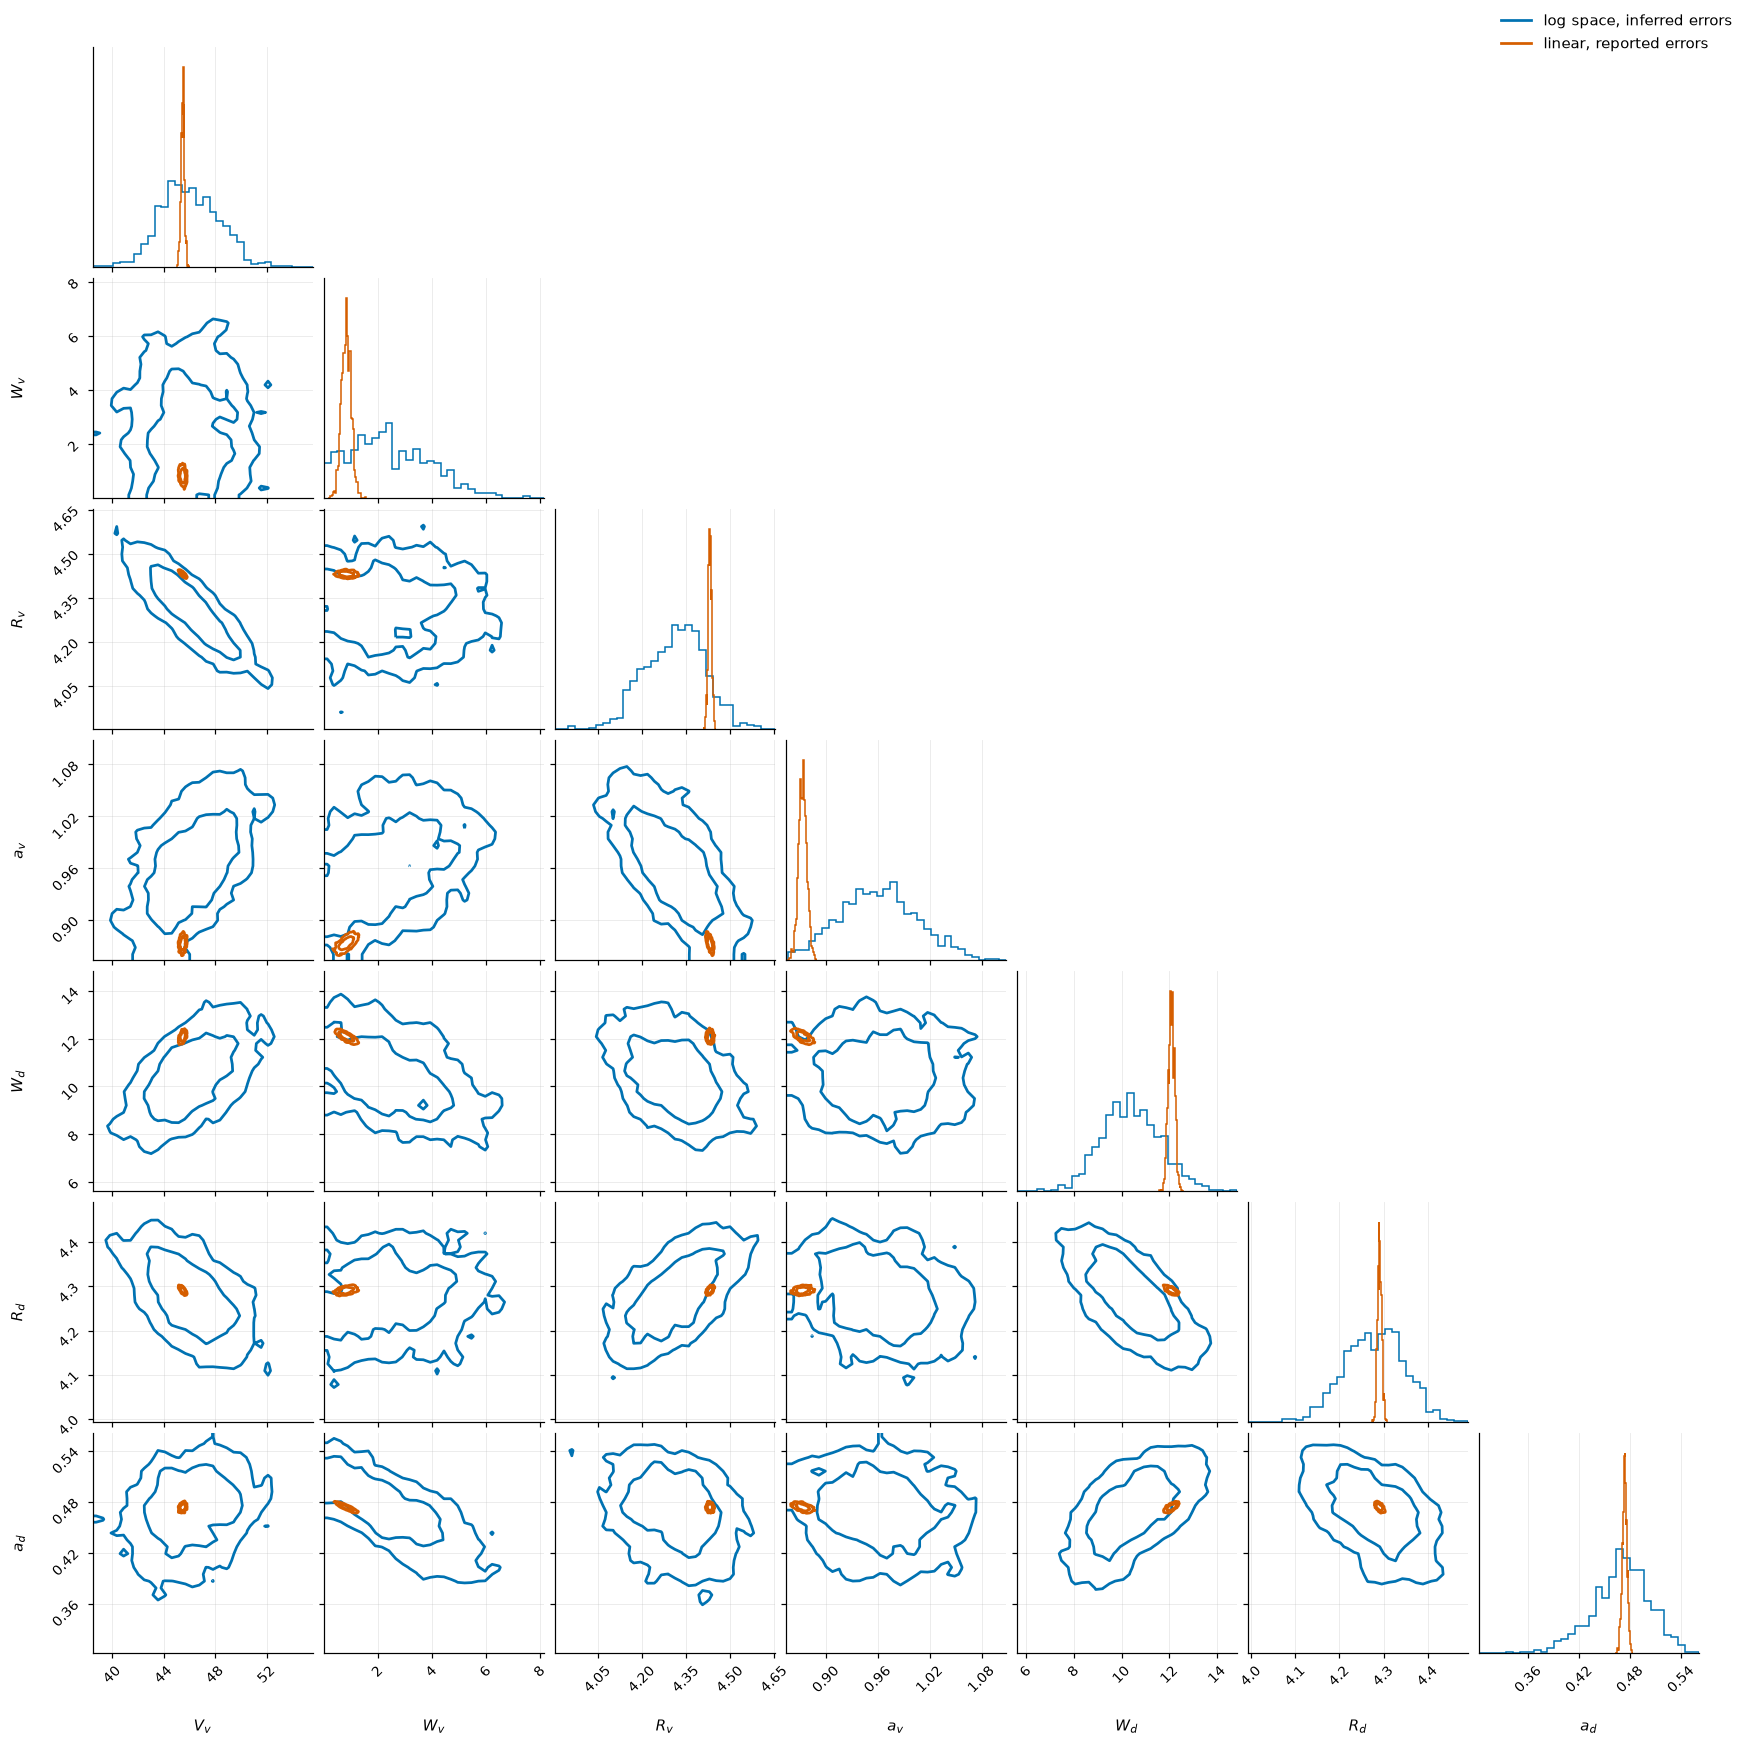

In [18]:
fig = None
for name, p in problems.items():
    fig = corner.corner(
        samples[name][:, p.columns(params)],
        fig=fig,
        labels=[f"${lt}$" for lt in latex],
        **plotstyle.corner_kwargs(
            color=colours[name],
            fill_contours=False,
            plot_density=False,
            show_titles=False,
            levels=(0.68, 0.95),
        ),
    )
fig.legend(
    handles=[plt.Line2D([], [], color=c, label=n) for n, c in colours.items()],
    loc="upper right",
    fontsize=10,
)
plt.show()

The two posteriors tell very different stories about the same potential. Taking the reported errors at their word, the linear fit pins $V_v$ to $45.5 \pm 0.1$ MeV, and its best potential still sits $\chi^2/N = 122$ away from the data. It's precise, but the precision is meaningless, because it comes from pretending the misfit is noise.

The log-space fit lands at a similar depth, $V_v = 46.0 \pm 2.3$ MeV, with an honest width. It gets there by inferring a point-to-point relative error of $s = 34\,\% \pm 7\,\%$: that's how well a local Woods–Saxon describes this measurement angle by angle. The common error $b$ is barely constrained, $37\,\% \pm 36\,\%$. That makes sense. A single measurement can't tell a coherent shift of all its points apart from the potential itself moving, so the posterior for $b$ mostly reflects its prior.

In the corner plot the linear posterior is a tight speck inside the log-space one, and for several parameters ($W_d$, $a_v$) it sits near the edge of the log-space contours.

## (B) The posterior predictive

There are two predictive distributions we care about, and it's worth being precise about them:

- **(B1) The potential alone**, $y_m(\theta;\alpha)$ with $\alpha$ drawn from the posterior. This is our uncertainty about the cross section the potential predicts, and it's what we'd hand to a transport code.
- **(B2) The potential plus every error term**: the reported statistical errors, and for the first model the inferred $s$ and $b$. This is our uncertainty about what a *measurement* would read, and it's the one that belongs next to the data.

B1 has a value at any angle, so we draw it on a fine grid with `rx.predictive.grid_draws`. B2 is different. The reported statistical errors are one number per *measured* angle, and at an angle nobody measured there's simply no statistical error to draw, so `grid_draws` refuses them (recipe 40, and the forecasting discussion in `linear_calibration`). We therefore draw B2 at the 59 measured angles with `rx.diagnostics.predictive_draws`, and show each interval as a vertical bar at its angle. The inferred terms, on the other hand, *are* functions of angle, so for the first model we can also show the potential plus $s$ and $b$ on the fine grid.

`physical=True` returns the log-space draws as ratios, so every band is in the units of the data.

In [19]:
x_fine = np.deg2rad(np.linspace(3.0, 175.0, 140))
on_fine = omp.bind(x_fine, data.meta)
fine, at_data = {}, {}
for i, (name, p) in enumerate(problems.items()):
    rows = samples[name][::20]
    space = tf.log if name.startswith("log") else None
    fine[name] = {
        "potential alone": rx.predictive.grid_draws(
            p, on_fine, x_fine, rows, model_only=True, physical=True, levels=(5, 95)
        )
    }
    if inferred_terms[name]:
        fine[name]["potential + inferred terms"] = rx.predictive.grid_draws(
            p, on_fine, x_fine, rows, terms=inferred_terms[name], n_rep=2,
            physical=True, levels=(5, 95), rng=4,
        )  # fmt: skip
    draws = rx.diagnostics.predictive_draws(p, rows, n_rep=2, rng=4, return_draws=True)
    draws = np.exp(draws) if space is not None else draws
    at_data[name] = np.percentile(draws, [5, 95], axis=0)

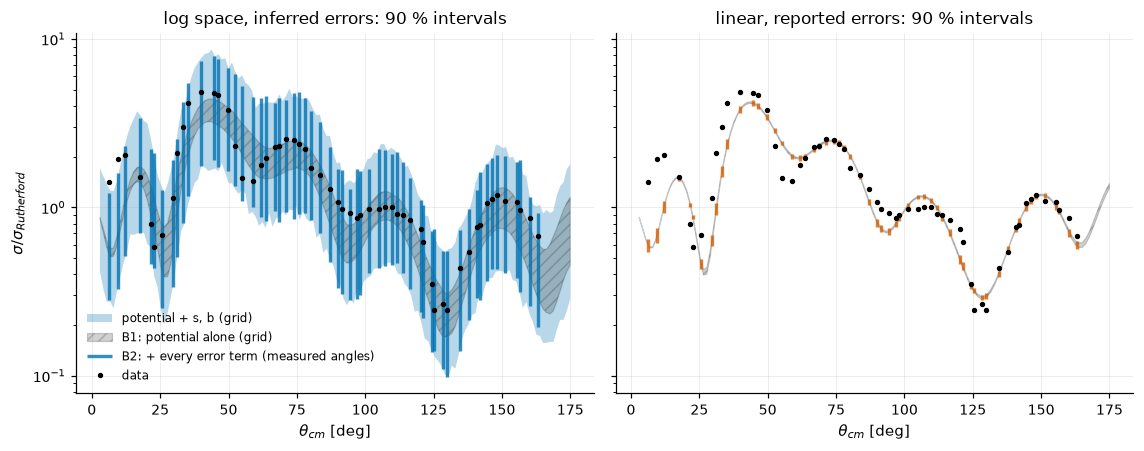

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), sharey=True)
for ax, name in zip(axes, problems):
    colour = colours[name]
    if "potential + inferred terms" in fine[name]:
        lo, hi = fine[name]["potential + inferred terms"]
        plotstyle.band(
            ax,
            np.rad2deg(x_fine),
            lo,
            hi,
            color=colour,
            label="potential + s, b (grid)",
        )
    lo, hi = fine[name]["potential alone"]
    plotstyle.band(
        ax,
        np.rad2deg(x_fine),
        lo,
        hi,
        color="k",
        hatch=plotstyle.HATCHES[0],
        label="B1: potential alone (grid)",
    )
    ax.vlines(
        np.rad2deg(data.x),
        *at_data[name],
        color=colour,
        lw=2.2,
        alpha=0.8,
        label="B2: + every error term (measured angles)",
    )
    ax.plot(np.rad2deg(data.x), data.y, "o", ms=2.5, color="k", label="data")
    ax.set(xlabel=r"$\theta_{cm}$ [deg]", yscale="log", title=f"{name}: 90 % intervals")
axes[0].set_ylabel(r"$\sigma / \sigma_{Rutherford}$")
axes[0].legend(fontsize=8, loc="lower left")
fig.tight_layout()
plt.show()

On the left, the potential alone (the hatched grey band, B1) is already wide, because the fit is honest about how well it knows the potential. Adding $s$ and $b$ on the fine grid widens it further, and the vertical bars (B2) show each measured angle's full 90 % interval, which is where we compare with the data. On the right, the reported-errors fit gives a razor-thin potential and intervals barely larger than the points themselves, and most of the data sit visibly outside them.

## (C) Empirical coverage

A predictive distribution is calibrated if its central 68 % interval contains about 68 % of the measured points, and likewise at every level, so its empirical [coverage](https://en.wikipedia.org/wiki/Coverage_probability) follows the diagonal (recipe 17). We check three predictives for each model, all at the measured angles:

- **(C1) the potential alone** (`model_only=True`);
- **the potential plus the reported statistical errors** (`terms=[]`, which keeps `statistical=True` and drops every inferred term);
- **(C2) the potential plus every error term** (the default).

For the linear model the last two are the same thing, because the reported errors are its only term, so its two curves lie on top of each other.

In [21]:
levels = np.linspace(0.05, 0.95, 19)
kinds = {
    "potential alone": dict(model_only=True),
    "+ statistical errors": dict(terms=[]),
    "+ every error term": {},
}
coverage, cov68 = {}, {}
for i, (name, p) in enumerate(problems.items()):
    c = p.constraints[0]
    rows = samples[name][::20]
    coverage[name], cov68[name] = {}, {}
    for kind, kw in kinds.items():
        extra = {} if kw.get("model_only") else dict(n_rep=2, rng=10 + i)
        draws = rx.diagnostics.predictive_draws(
            p, rows, return_draws=True, **kw, **extra
        )
        y_obs = c.y[c.active]
        coverage[name][kind] = rx.diagnostics.coverage_curve(draws, y_obs, levels)
        cov68[name][kind] = rx.diagnostics.coverage_curve(draws, y_obs, [0.68])[0]

In [22]:
for name, row in cov68.items():
    print(f"{name}: coverage at a nominal 68 %")
    for kind, value in row.items():
        print(f"    {kind:22s} {value:.2f}")

log space, inferred errors: coverage at a nominal 68 %
    potential alone        0.29
    + statistical errors   0.31
    + every error term     0.83
linear, reported errors: coverage at a nominal 68 %
    potential alone        0.02
    + statistical errors   0.15
    + every error term     0.15


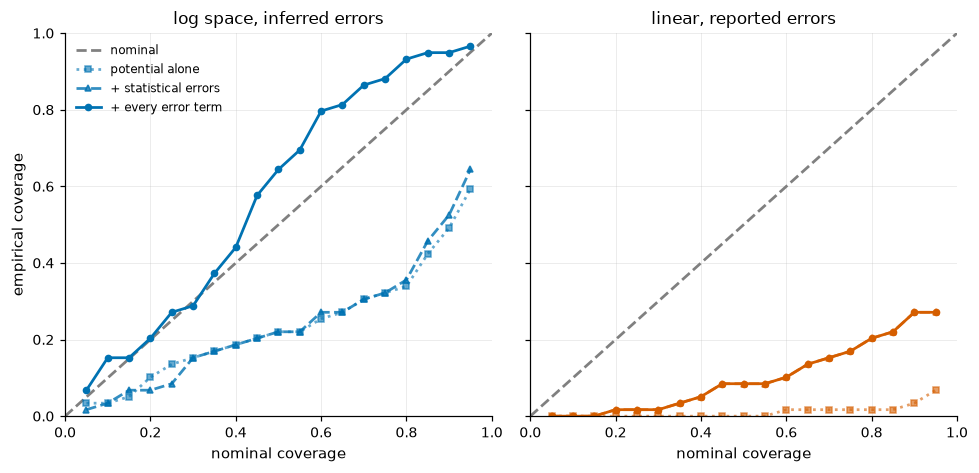

In [23]:
styles = {
    "potential alone": ("s:", 0.6),
    "+ statistical errors": ("^--", 0.8),
    "+ every error term": ("o-", 1.0),
}
fig, axes = plt.subplots(1, 2, figsize=(9.0, 4.4), sharey=True)
for ax, name in zip(axes, problems):
    ax.plot([0, 1], [0, 1], "--", color="0.5", label="nominal")
    for kind, (marker, alpha) in styles.items():
        ax.plot(
            levels,
            coverage[name][kind],
            marker,
            ms=4,
            color=colours[name],
            alpha=alpha,
            label=kind,
        )
    ax.set(
        xlabel="nominal coverage",
        xlim=(0, 1),
        ylim=(0, 1),
        title=name,
    )
axes[0].set_ylabel("empirical coverage")
axes[0].legend(fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

Here are the numbers at a nominal 68 %:

| | potential alone | + statistical errors | + every error term |
|---|---|---|---|
| log space, inferred errors | 0.29 | 0.31 | 0.83 |
| linear, reported errors | 0.02 | 0.15 | 0.15 |

For the linear model, even the full predictive covers only 15 % of the points at a nominal 68 %. The reported errors aren't a sufficient description of the disagreement.

For the log-space model, adding the reported statistical errors to the potential barely changes anything, because 2.3 % is small next to the 34 % the potential is uncertain by. Adding the inferred terms brings the curve up to the diagonal, and then a little past it: 83 % at a nominal 68 %. That over-coverage mostly comes from $b$. Its posterior is wide, so the predictive draws include some large common shifts that the data never needed.

The potential alone undercovers in both models, as it should. It describes the curve the potential predicts, not what a measurement would read.

## The guardrail: a covariance that can't be factored (recipe 21)

Sometimes a subentry reports no statistical error at all. Then the covariance of those points is singular, and there's nothing sensible to do with it. The library says so when the problem is built, naming the dataset, rather than failing somewhere inside the sampler an hour later.

In [24]:
no_errors = rx.Dataset(
    data.x[:6],
    data.y[:6],
    np.zeros(6),
    label="a subentry with no errors",
    meta=data.meta,
)
try:
    rx.Problem([rx.Constraint([rx.Comparison(no_errors, omp)])])
except ValueError as err:
    print(err)

the constraint's covariance is singular on its active points; the diagonal is zero on rows of ['a subentry with no errors']: those comparisons have zero statistical error and no diagonal term covers their points (a block covered only by correlated modes is singular here even when the full covariance is not).  Remedies: comparison.reported_terms(), a noise term, a fixed Term covering those points, or statistical=False with an explicit covariance.


## Takeaways

- `from_measurement` is the unit contract, and it takes an `exfor_tools` `Distribution` or a plain `dict`.
- Real data arrive with whatever the experimenters chose to report, and often that's statistics only. How the potential and the data are allowed to disagree is then *our* declaration. Declaring nothing is itself a strong claim, and here the evidence rejects it by about 3441 in $\log Z$.
- A log-space comparison with a point-to-point and a common relative error, as in `jitr`, describes this measurement to about 34 % per angle, and gives the potential's parameters widths we can believe.
- Evidences from different comparison spaces are only comparable once the Jacobian is added.
- The potential alone and a prediction of a measurement are different distributions, and they need different coverage checks. Only the second should follow the diagonal.
- Reported per-point errors live at the measured angles. Terms written as functions of the angle, like $s$ and $b$ here, can be drawn anywhere.